In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


D = 20
CHANGE_TIME = 500
BOX_TIMES = (500, 510, 520, 530, 540)
N_RUNS = 200
N_PATHS = 200
PATH_HORIZON = 1000
M_FEATURES = 500             
REF_SIZE = 500
BOX_SEED = 456 + 5_100_000 + 10_000 * D
PATH_SEED = 98765 + 10_000 * D
LAMBDA0 = LAMBDA1 = 1 - 1e-3
ETA = 1e-2
LAMBDA_CLIP = (1e-3, 1 - 1e-3)

OUTPUT_DIR = Path.cwd() / "OKAFF_Gaussian_boxes_sample_paths"
BOX_DIR = OUTPUT_DIR / "prepost_boxes"
PATH_DIR = OUTPUT_DIR / "sample_paths"

# The six alternatives
GAUSSIAN_ALTERNATIVES = [
    ("gaussian_scale_0p1", r"$\mathcal{N}(\mathbf{0},0.1\mathbf{I})$", 0.0, 0.1, None),
    ("gaussian_scale_4",   r"$\mathcal{N}(-1\mathbf{1},0.1\mathbf{I})$", -1.0, 0.1, None),
    ("gaussian_scale_0p5", r"$\mathcal{N}(\mathbf{0},\mathbf{\Sigma}_{0.1})$", 0.0, None, (0.1, 0.05)),
    ("gaussian_scale_2",   r"$\mathcal{N}(\mathbf{0},\mathbf{\Sigma}_{3})$", 0.0, None, (3.0, 1.5)),
    ("gaussian_scale_3",   r"$\mathcal{N}(\mathbf{0},3\mathbf{I})$", 0.0, 3.0, None),
    ("gaussian_scale_5",   r"$\mathcal{N}(2\mathbf{1},4\mathbf{I})$", 2.0, 4.0, None),
]
assert BOX_TIMES[0] == CHANGE_TIME and all(t > CHANGE_TIME for t in BOX_TIMES[1:])


In [2]:
class AdaptiveForgettingFactor:
    def __init__(self, feat_func):
        self.feat_func = feat_func
        self.lambda_t = float(LAMBDA0)
        self.m = self.Lm = None
        self.w = self.Lw = 0.0
        self.k = 0

    def update_stat(self, new_sample):
        temp = self.feat_func(new_sample)
        if self.m is None:
            self.m = np.zeros_like(temp)
            self.Lm = np.zeros_like(temp)

        lam_used = self.lambda_t
        if self.w > 0:
            ybar_k = self.m / self.w
            Lybar_k = (self.Lm - ybar_k * self.Lw) / self.w
        else:
            ybar_k = np.zeros_like(self.m)
            Lybar_k = np.zeros_like(self.m)

        m_next = lam_used * self.m + temp
        w_next = lam_used * self.w + 1.0
        Lm_next = self.m + lam_used * self.Lm
        Lw_next = self.w + lam_used * self.Lw
        self.m, self.w = m_next, w_next
        self.Lm, self.Lw = Lm_next, Lw_next
        ybar_next = self.m / self.w
        stat = float(np.vdot(ybar_next, ybar_next).real)
        self.k += 1
        if self.k == 1:
            self.lambda_t = float(np.clip(LAMBDA1, *LAMBDA_CLIP))
        else:
            grad = 2.0 * float(np.dot(Lybar_k.ravel(), (ybar_k - temp).ravel()))
            self.lambda_t = float(np.clip(lam_used - ETA * grad, *LAMBDA_CLIP))
        return stat


def make_gaussian_sampler(mean, scale, covariance_params):
    if covariance_params is None:
        def sample(rng, n):
            return mean + np.sqrt(scale) * rng.normal(size=(int(n), D))
    else:
        diagonal, off_diagonal = covariance_params
        covariance = ((diagonal - off_diagonal) * np.eye(D)
                      + off_diagonal * np.ones((D, D)))
        chol = np.linalg.cholesky(covariance)
        def sample(rng, n):
            return rng.normal(size=(int(n), D)) @ chol.T
    return sample


def make_detector(reference_rng):
    reference = reference_rng.normal(size=(REF_SIZE, D))
    sq_norms = np.sum(reference * reference, axis=1)
    sq_distances = np.maximum(
        sq_norms[:, None] + sq_norms[None, :] - 2.0 * (reference @ reference.T), 0.0
    )
    sigmasq = 0.5 * float(np.median(sq_distances[np.triu_indices(REF_SIZE, k=1)]))
    if not np.isfinite(sigmasq) or sigmasq <= 0:
        raise ValueError("RFF bandwidth must be finite and positive")
    W = reference_rng.normal(loc=0.0, scale=1.0 / np.sqrt(sigmasq), size=(M_FEATURES, D))

    def features(x):
        projection = W @ np.asarray(x, dtype=float)
        return np.concatenate([np.cos(projection), np.sin(projection)]) / np.sqrt(M_FEATURES)

    return AdaptiveForgettingFactor(features)


def simulate_runs(post_sampler, *, n_runs, horizon, seed, snapshot_times=None):
    master = np.random.default_rng(seed)
    snapshot_times = None if snapshot_times is None else tuple(snapshot_times)
    result = np.empty((n_runs, horizon if snapshot_times is None else len(snapshot_times)))
    for run in range(n_runs):
        reference_rng = np.random.default_rng(master.integers(0, 2**63 - 1))
        detector = make_detector(reference_rng)
        stream_rng = np.random.default_rng(master.integers(0, 2**63 - 1))
        snapshot_index = 0
        for t in range(1, horizon + 1):
            sampler = pre_sampler if t <= CHANGE_TIME else post_sampler
            statistic = detector.update_stat(sampler(stream_rng, 1)[0])
            if snapshot_times is None:
                result[run, t - 1] = statistic
            elif t == snapshot_times[snapshot_index]:
                result[run, snapshot_index] = statistic
                snapshot_index += 1
                if snapshot_index == len(snapshot_times):
                    break
    return result


pre_sampler = make_gaussian_sampler(0.0, 1.0, None)
post_samplers = {
    case_id: make_gaussian_sampler(mean, scale, covariance_params)
    for case_id, _, mean, scale, covariance_params in GAUSSIAN_ALTERNATIVES
}


In [3]:
box_values = {}
path_values = {}
for case_id, label, *_ in GAUSSIAN_ALTERNATIVES:
    print(f"Simulating {case_id} ({label})")
    post_sampler = post_samplers[case_id]
    box_values[case_id] = simulate_runs(
        post_sampler, n_runs=N_RUNS, horizon=max(BOX_TIMES),
        seed=BOX_SEED, snapshot_times=BOX_TIMES,
    )
    path_values[case_id] = simulate_runs(
        post_sampler, n_runs=N_PATHS, horizon=PATH_HORIZON,
        seed=PATH_SEED,
    )


Simulating gaussian_scale_0p1 ($\mathcal{N}(\mathbf{0},0.1\mathbf{I})$)
Simulating gaussian_scale_4 ($\mathcal{N}(-1\mathbf{1},0.1\mathbf{I})$)
Simulating gaussian_scale_0p5 ($\mathcal{N}(\mathbf{0},\mathbf{\Sigma}_{0.1})$)
Simulating gaussian_scale_2 ($\mathcal{N}(\mathbf{0},\mathbf{\Sigma}_{3})$)
Simulating gaussian_scale_3 ($\mathcal{N}(\mathbf{0},3\mathbf{I})$)
Simulating gaussian_scale_5 ($\mathcal{N}(2\mathbf{1},4\mathbf{I})$)


## boxplot for each alternative distribution — all point markers

In [4]:
BOX_DIR.mkdir(parents=True, exist_ok=True)
box_outputs = []
for case_id, label, *_ in GAUSSIAN_ALTERNATIVES:
    data = box_values[case_id]
    fig, ax = plt.subplots(figsize=(8.5, 5.8))
    box = ax.boxplot(
        [data[:, i] for i in range(len(BOX_TIMES))],
        positions=np.arange(len(BOX_TIMES)), widths=0.55,
        patch_artist=True, showfliers=False,
        medianprops={"color": "#141e2d", "linewidth": 1.8},
    )
    colors = ["#1853a4"] + ["#d67d2b"] * (len(BOX_TIMES) - 1)
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(0.72)
    for position, observations in enumerate(data.T):
        observations = observations[np.isfinite(observations)]
        indices = np.arange(len(observations), dtype=float)
        jitter = (((indices * 37) % 101) / 100.0 - 0.5) * 0.34
        ax.scatter(position + jitter, observations, s=11, color="#657386",
                   alpha=0.48, edgecolors="none", zorder=3)
    ax.set_xticks(range(len(BOX_TIMES)), [str(t) for t in BOX_TIMES])
    ax.set_xlabel("Time t", fontsize=27, fontweight="bold")
    ax.set_ylabel(r"Statistic Value $S_t$", fontsize=27, fontweight="bold", labelpad=30)
    ax.tick_params(axis="both", labelsize=13)
    for tick in [*ax.get_xticklabels(), *ax.get_yticklabels()]:
        tick.set_fontweight("bold")
    ax.grid(False)
    handles = [
        Line2D([], [], linestyle="none", marker="s", markersize=15.4,
               markerfacecolor=color, markeredgecolor=color, label=legend_label)
        for color, legend_label in zip(
            colors[:2], [r"Pre: $\mathcal{N}(\mathbf{0},\mathbf{I})$", f"Post: {label}"]
        )
    ]
    legend_location = "lower left" if case_id in {"gaussian_scale_2", "gaussian_scale_3"} else "best"
    legend_kwargs = (
        {"loc": "upper right", "bbox_to_anchor": (1.0, 1.0), "borderaxespad": 0.0}
        if case_id == "gaussian_scale_5" else {"loc": legend_location}
    )
    ax.legend(handles=handles, frameon=False, handlelength=0.7,
              handletextpad=0.5, prop={"size": 22, "weight": "bold"}, **legend_kwargs)
    fig.tight_layout()
    stem = f"gaussian_alternative_{case_id}_with_points"
    png, pdf = BOX_DIR / f"{stem}.png", BOX_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=220, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.close(fig)
    box_outputs.append(png)
    print(f"Saved {png} and {pdf}")


##  sample paths across Gaussian post-change cases

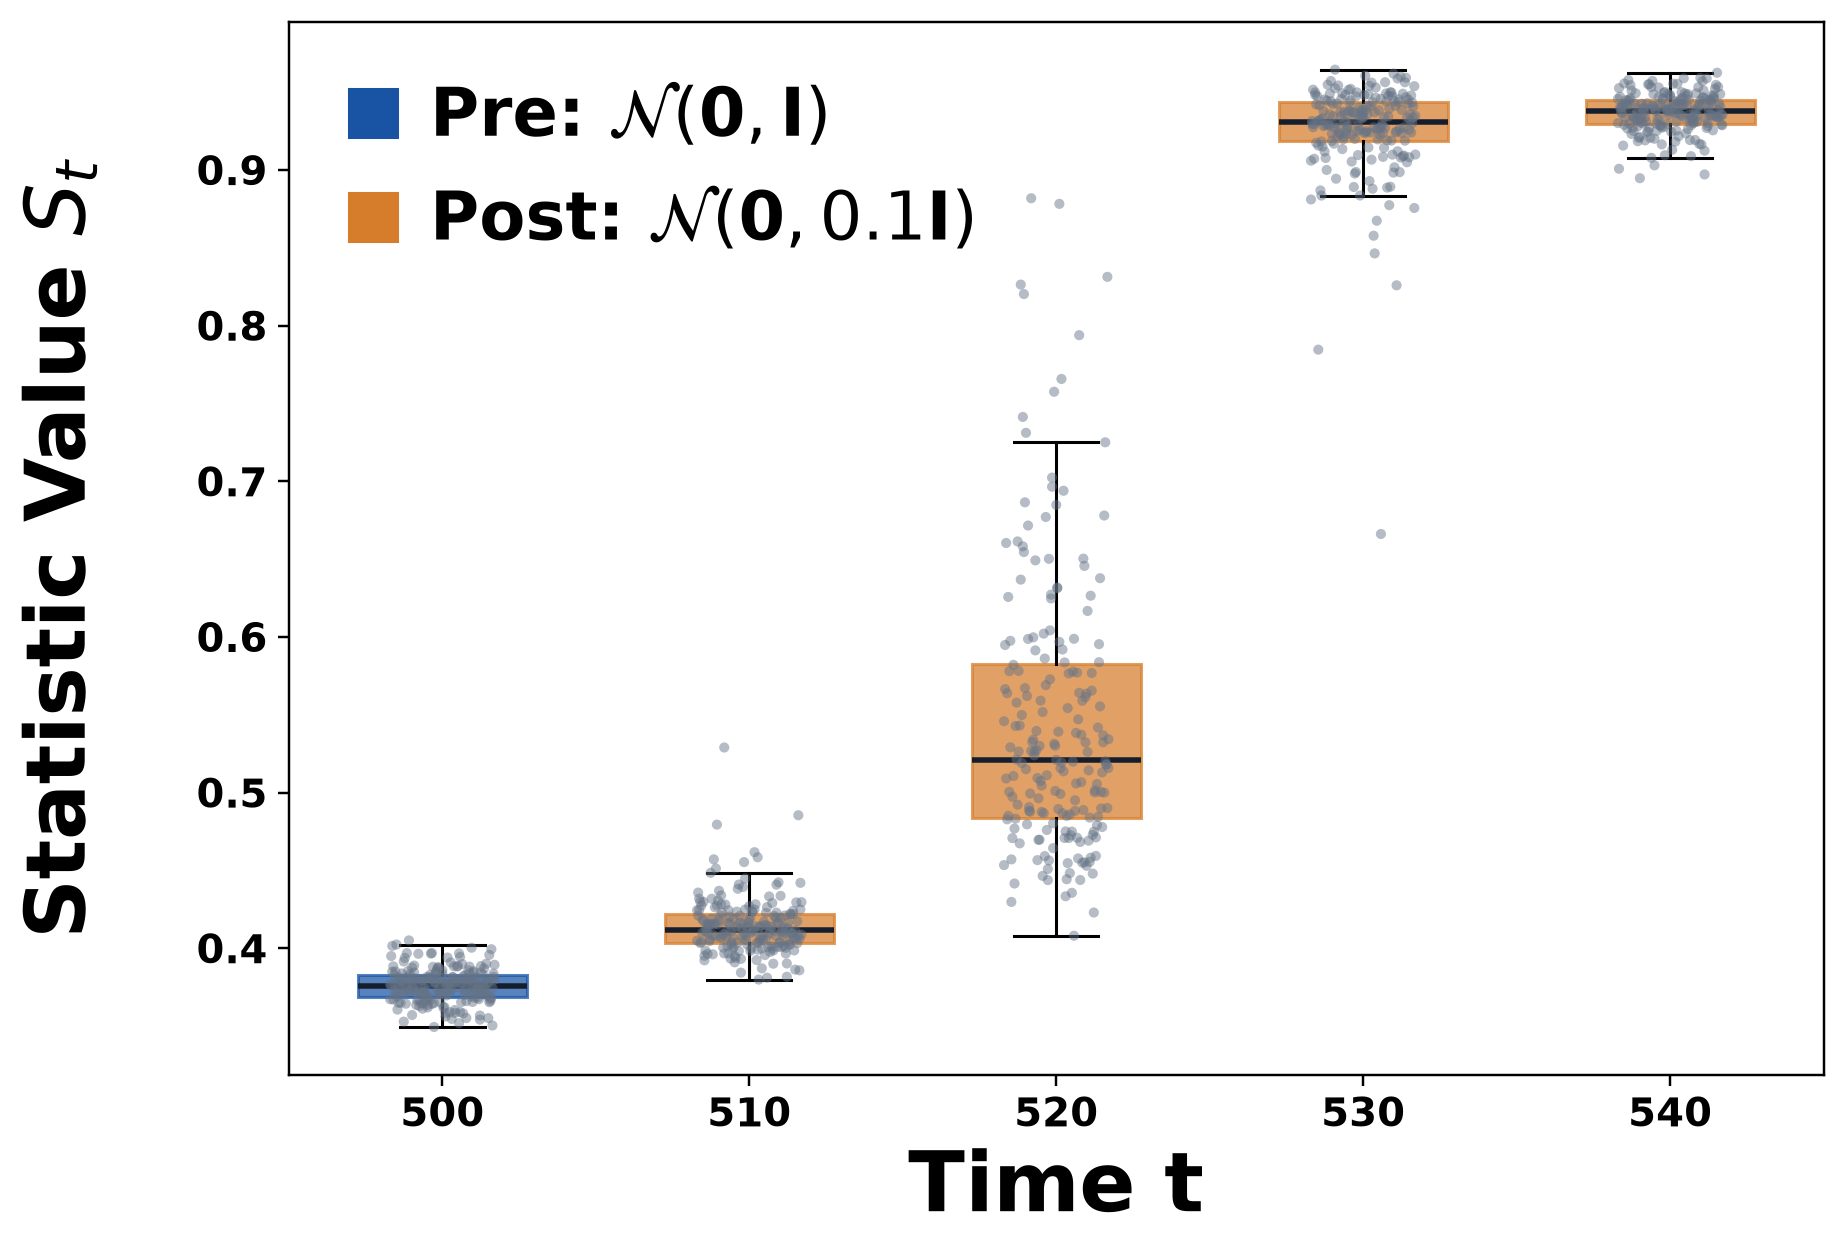

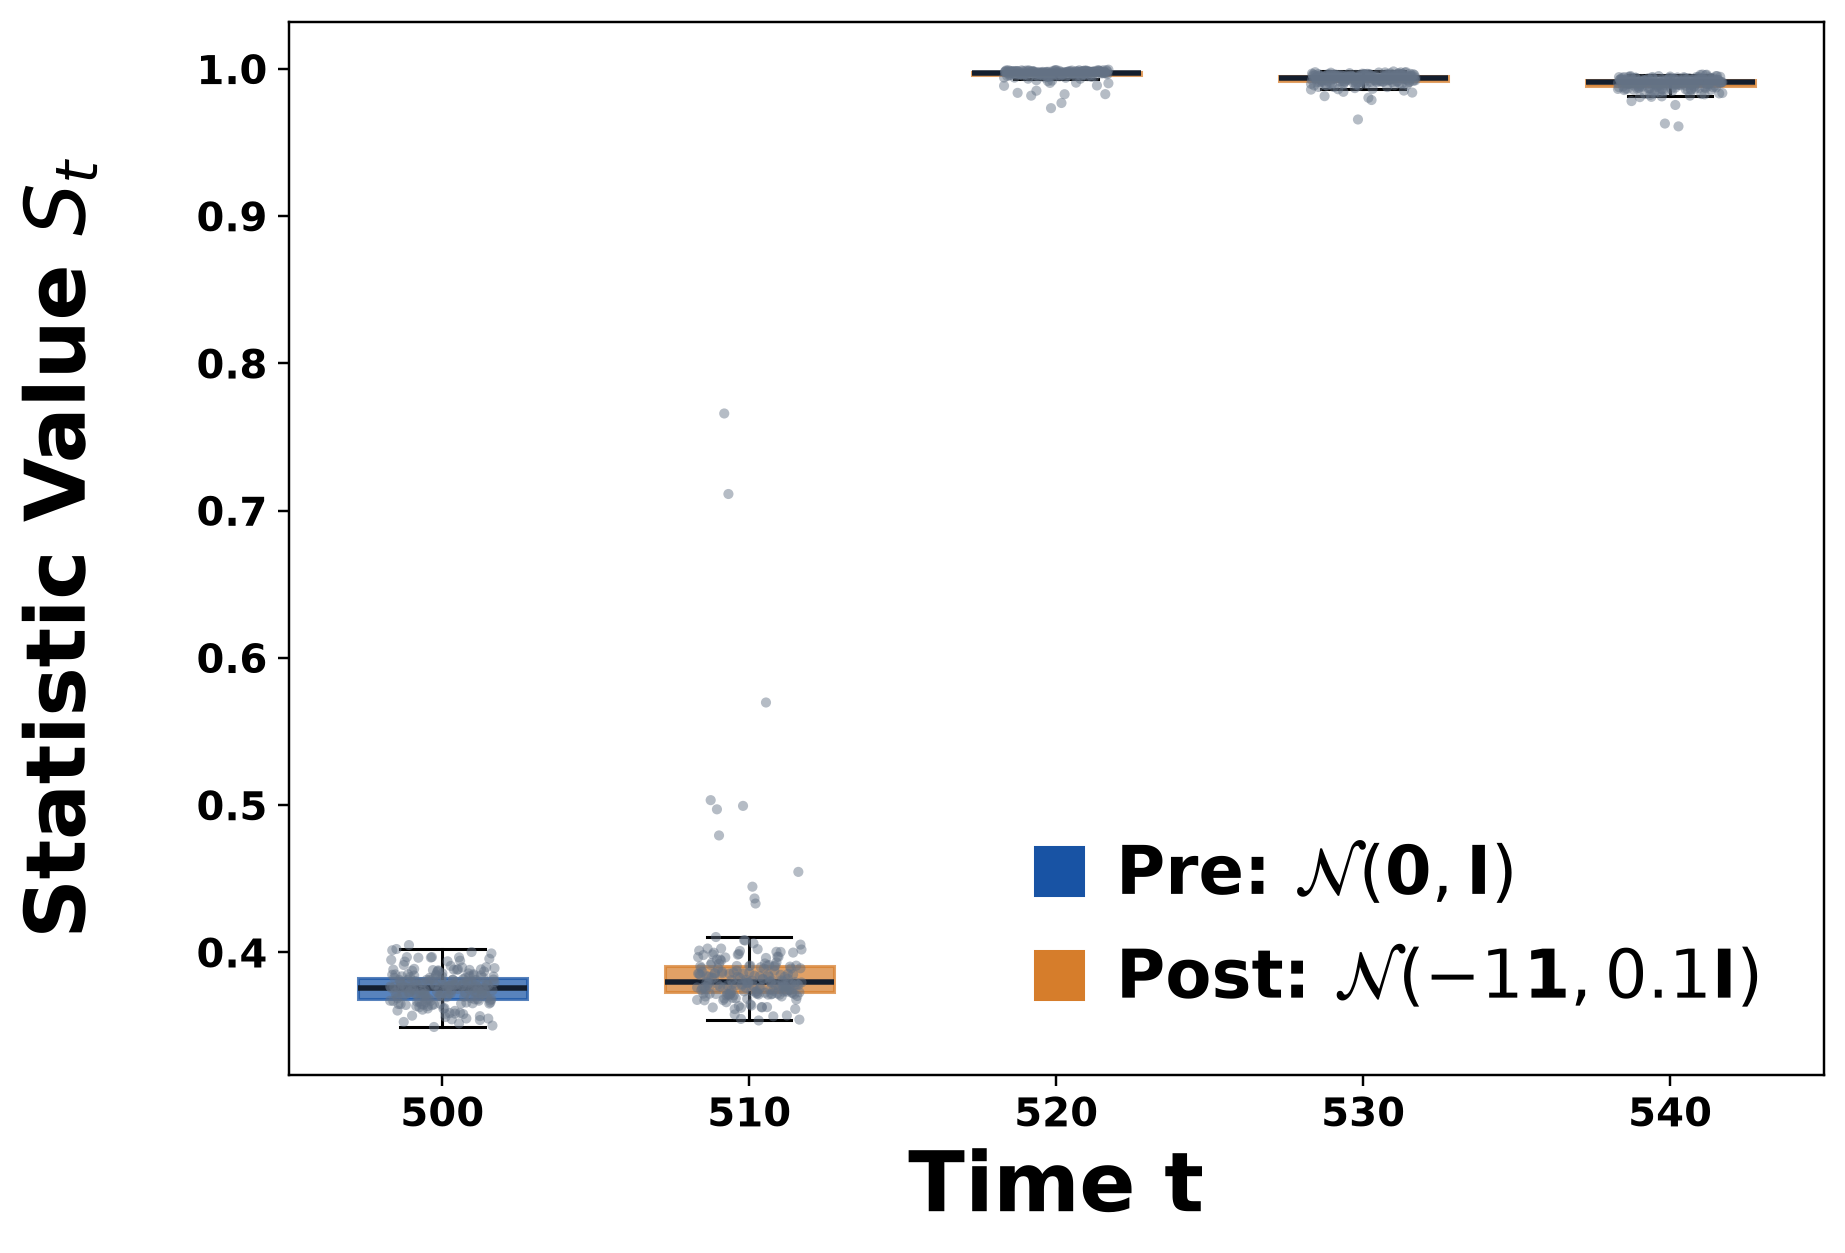

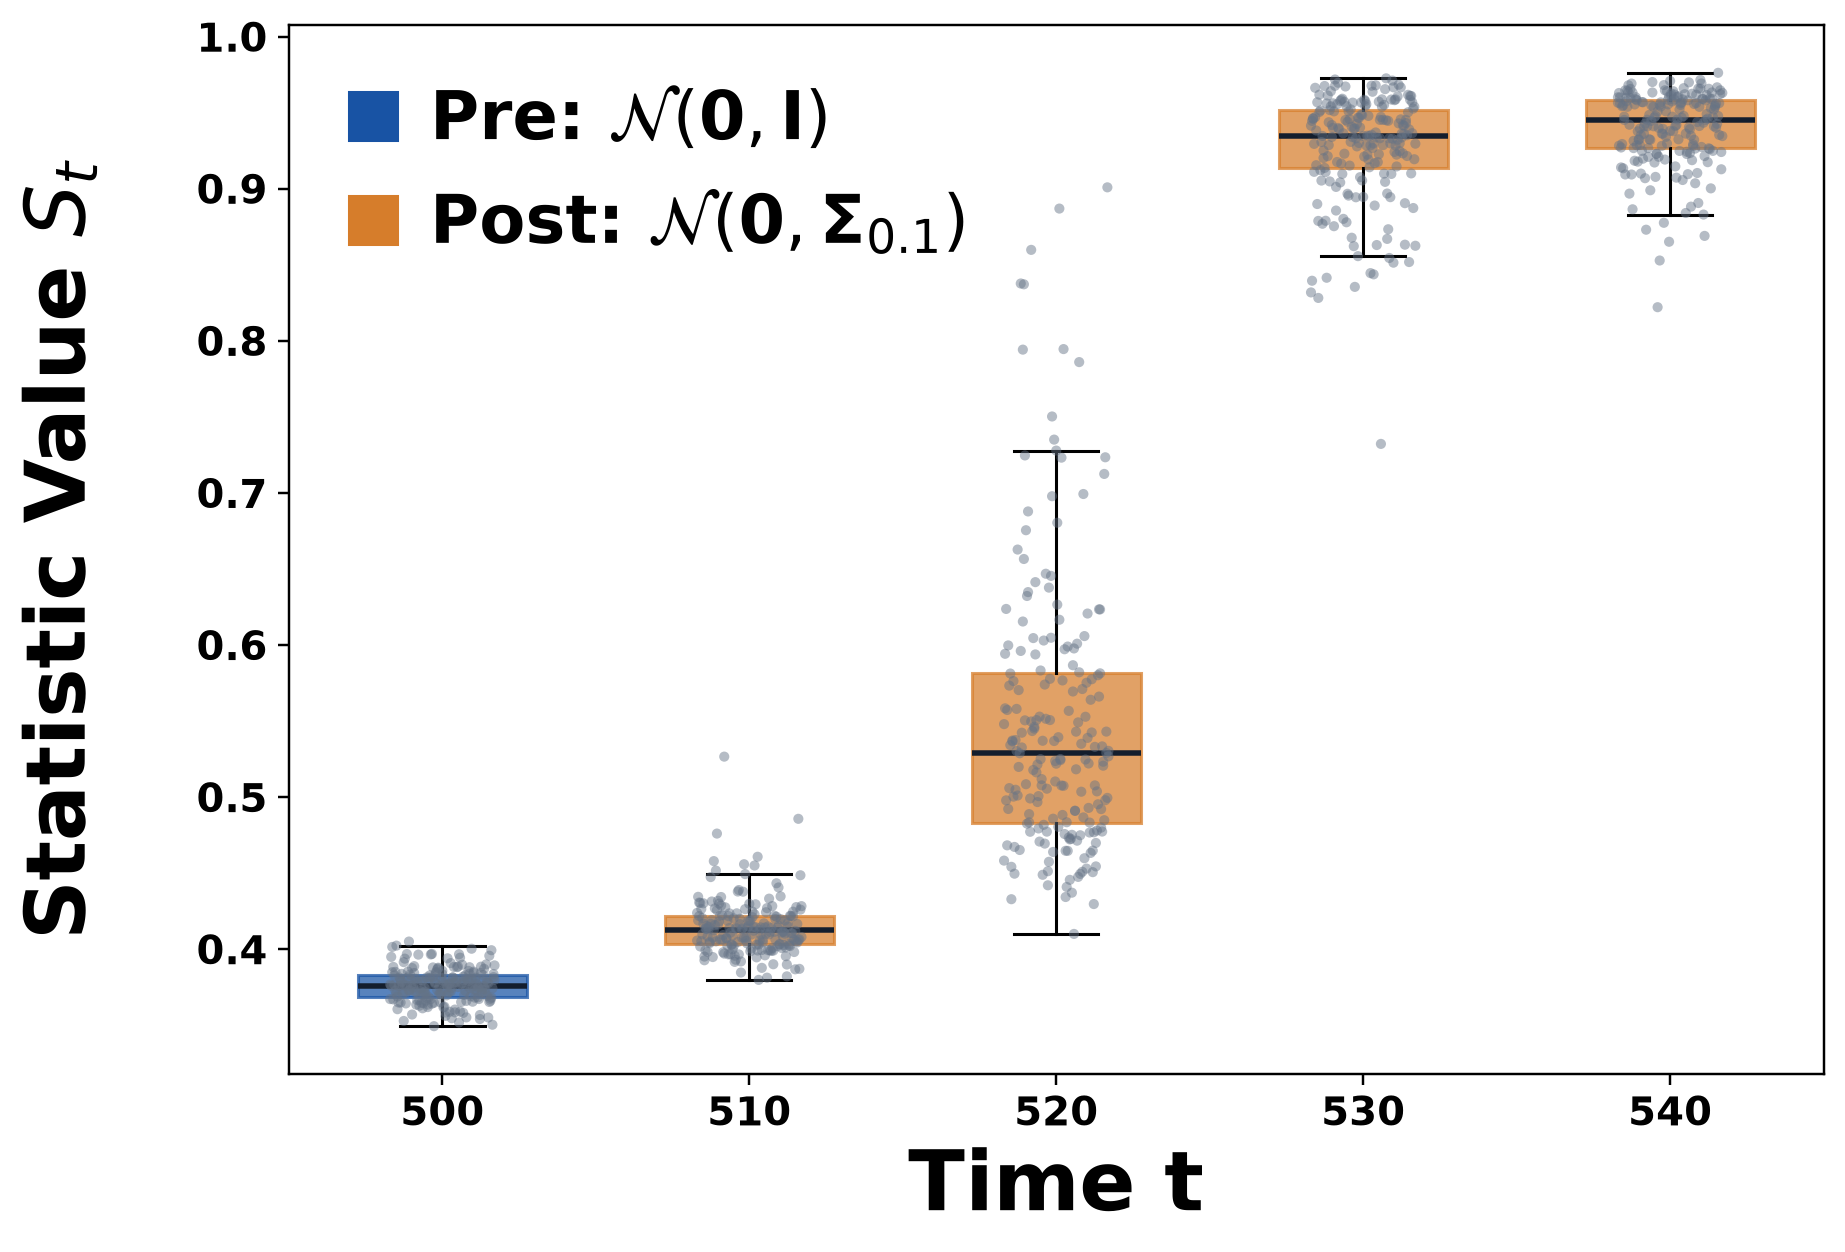

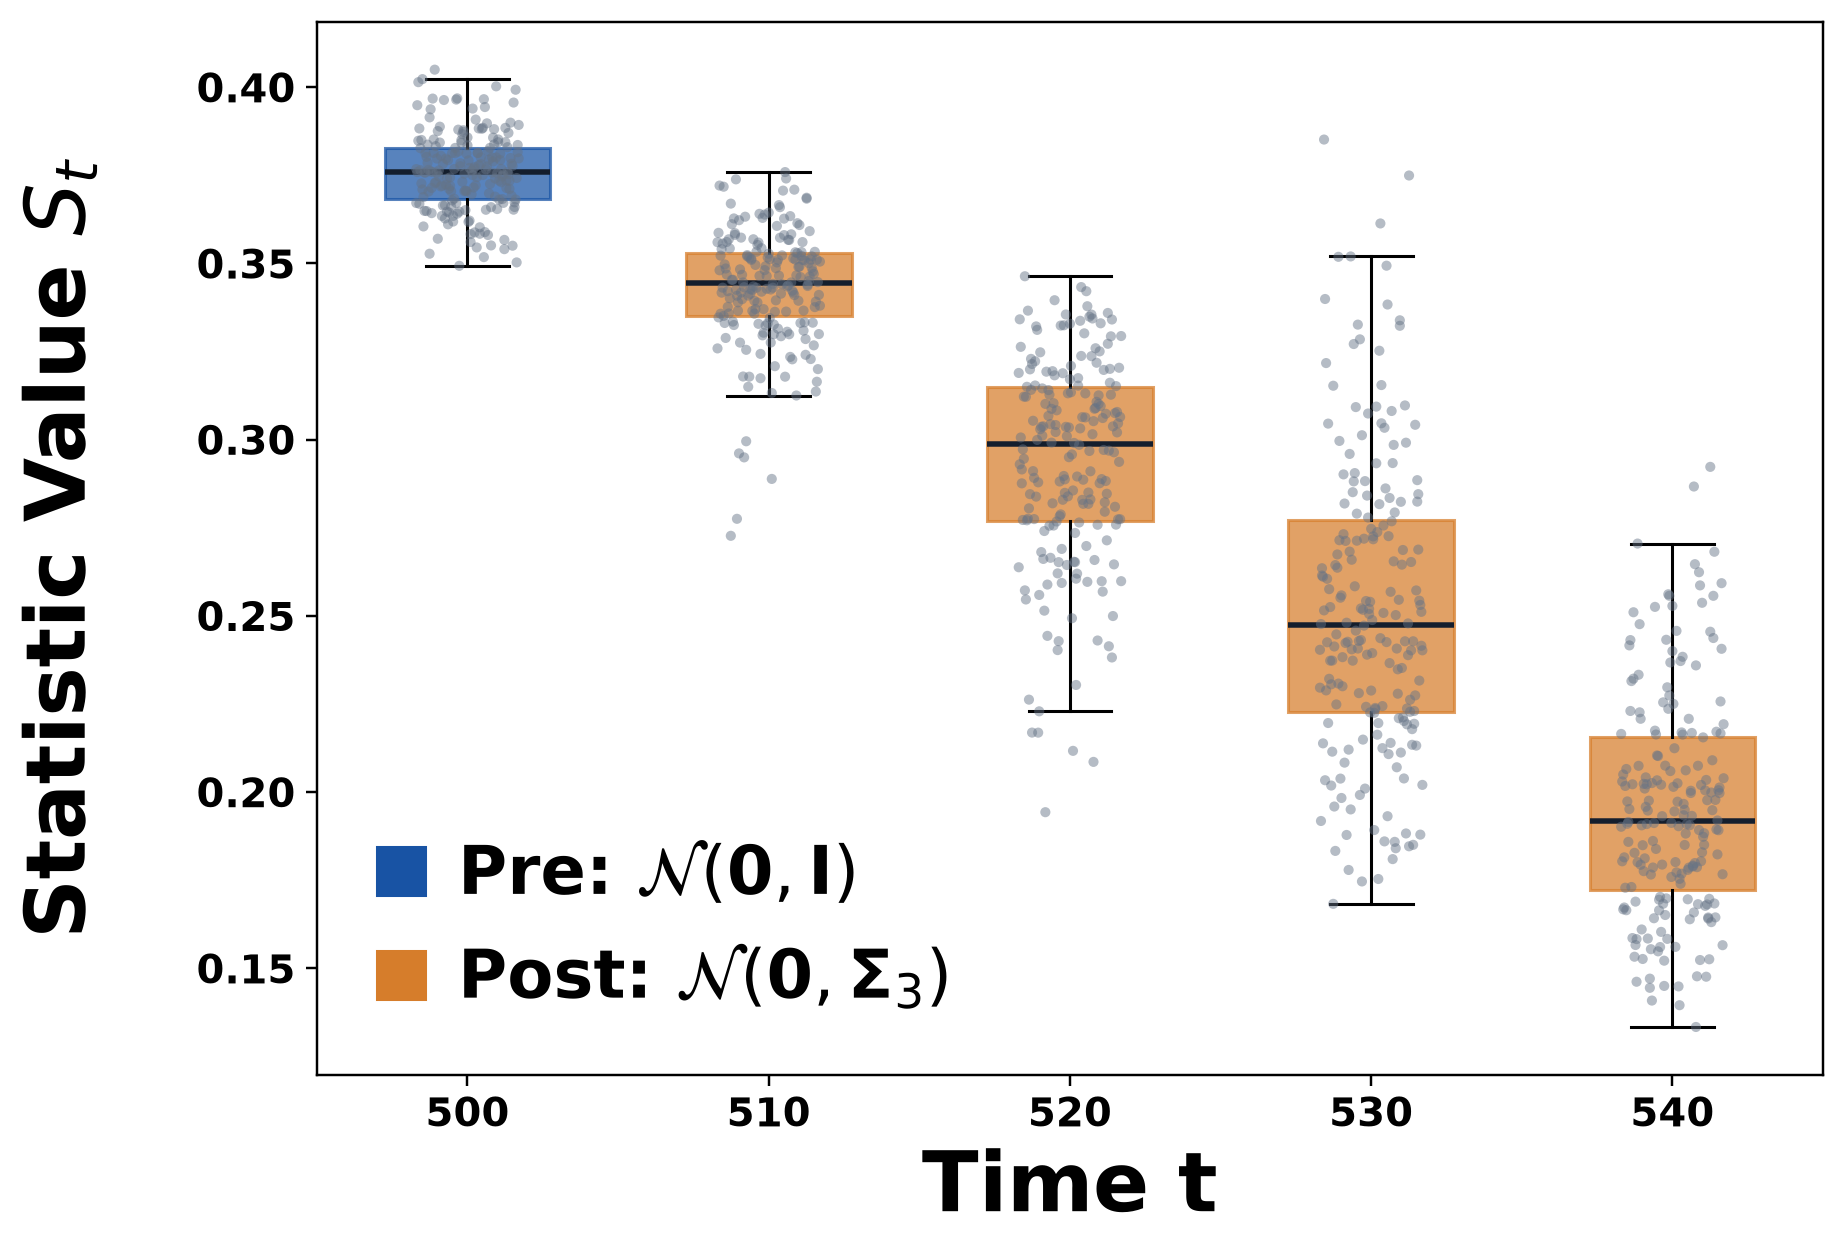

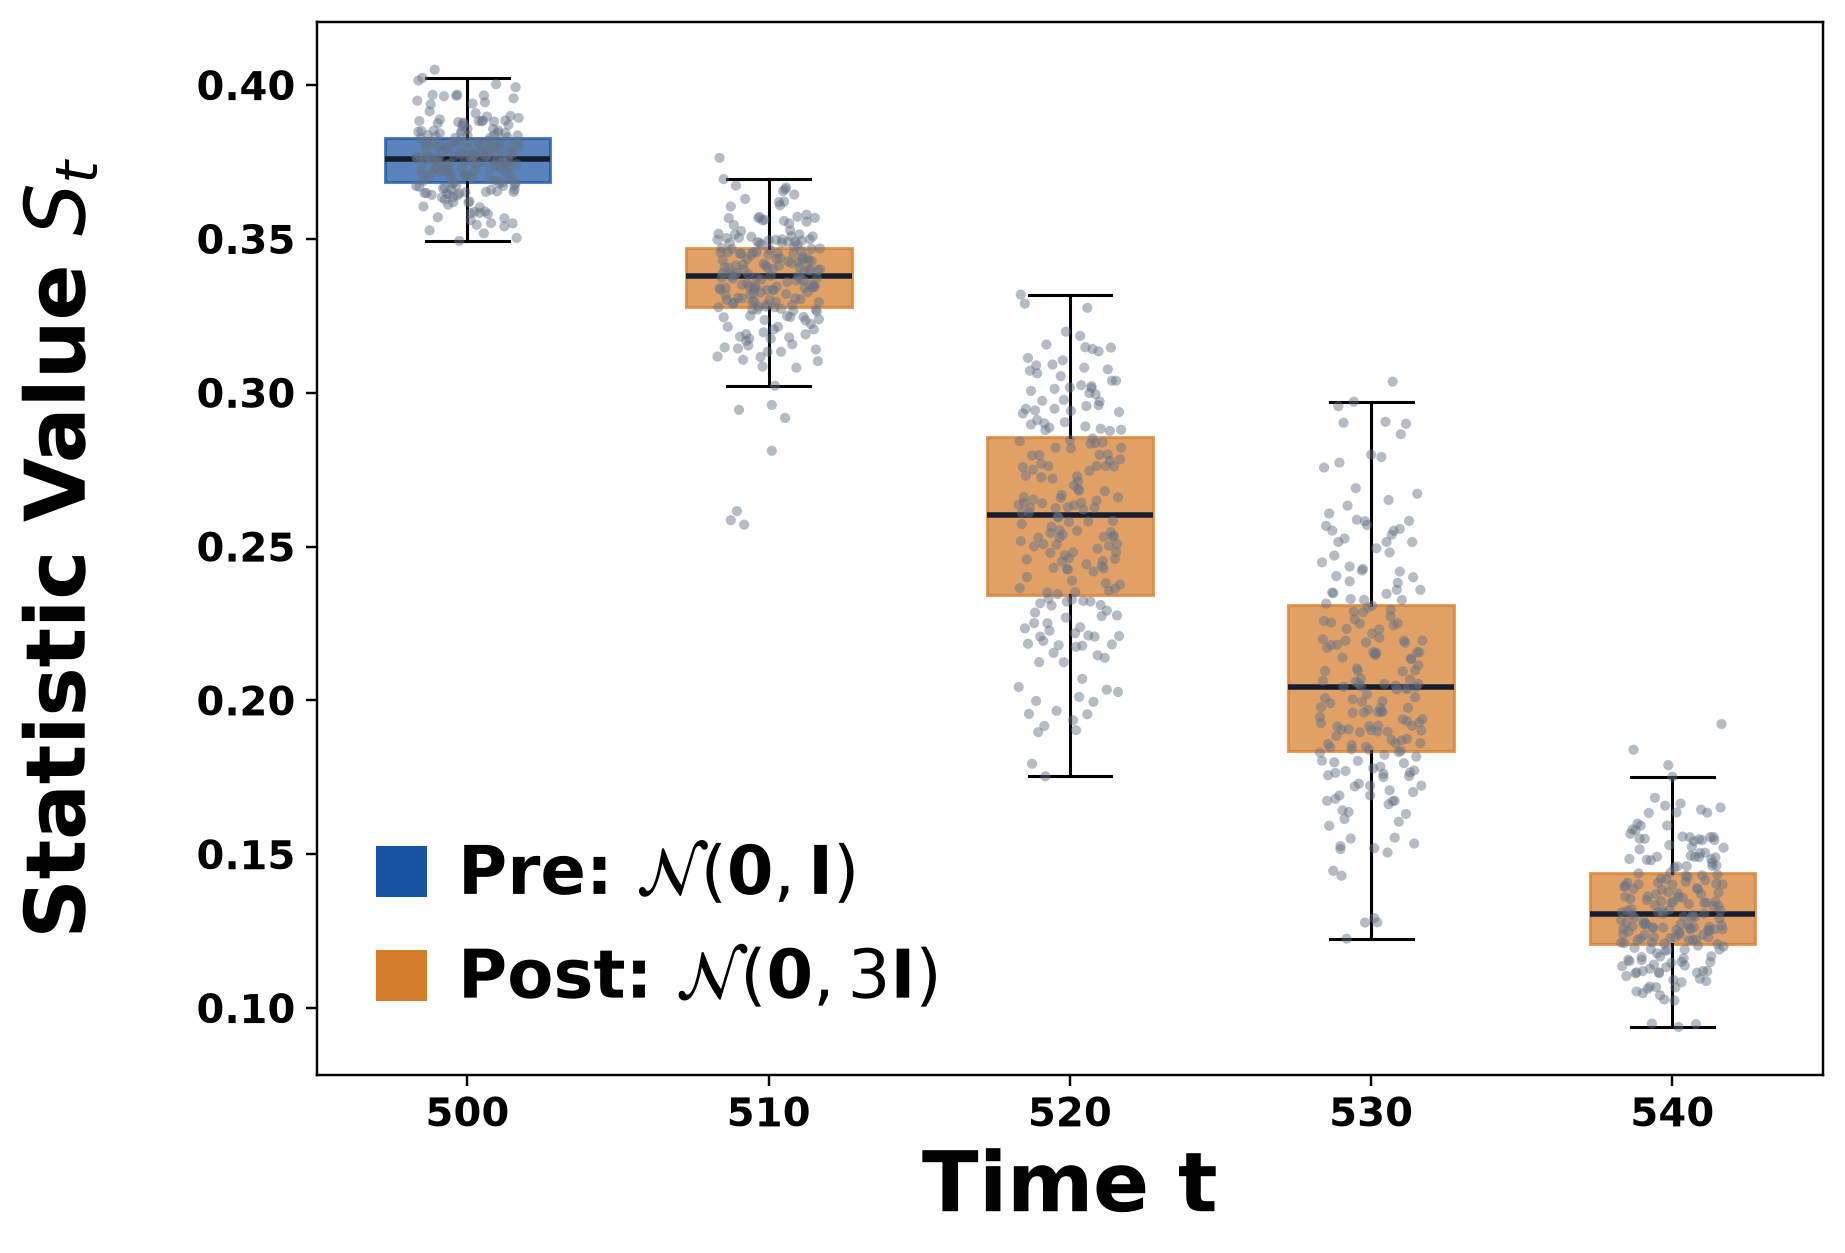

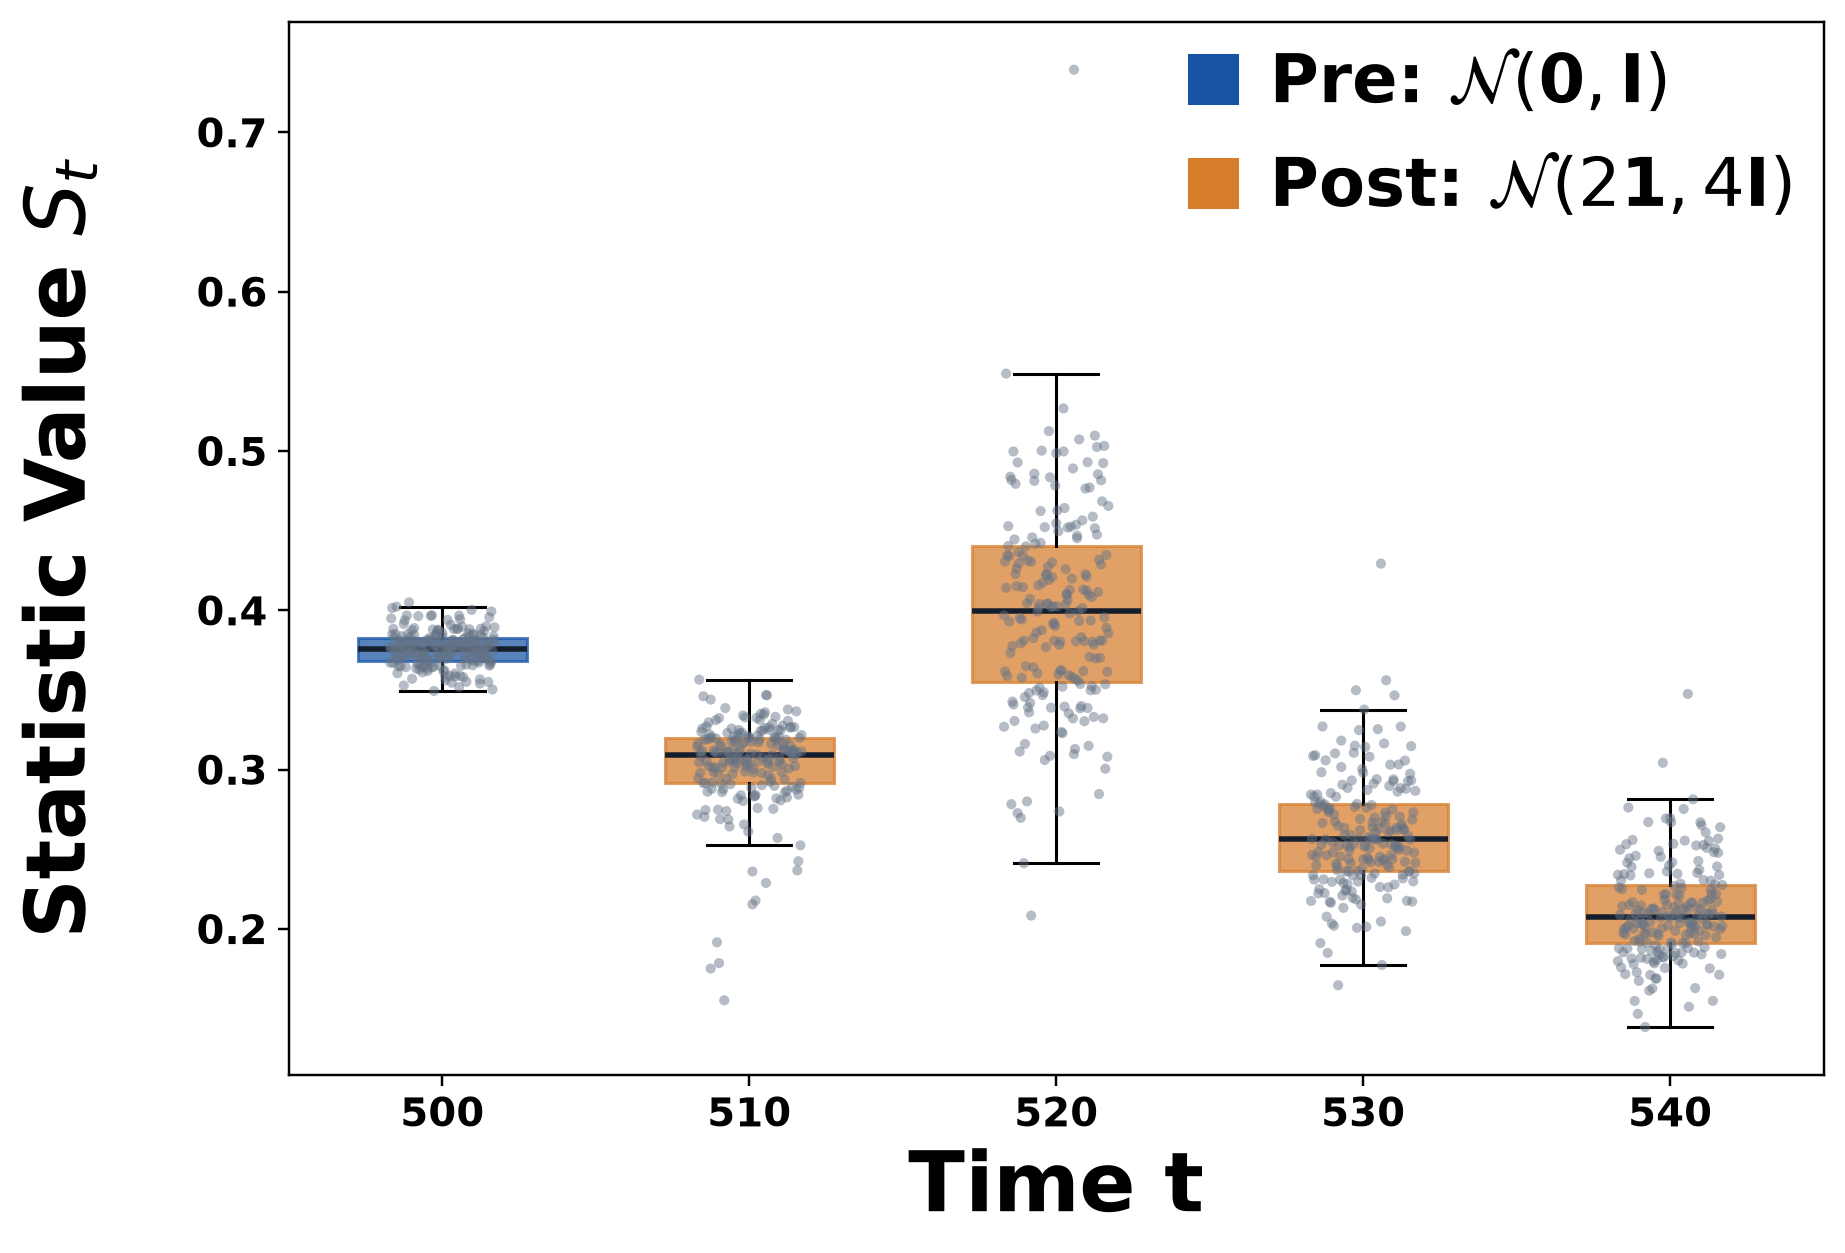

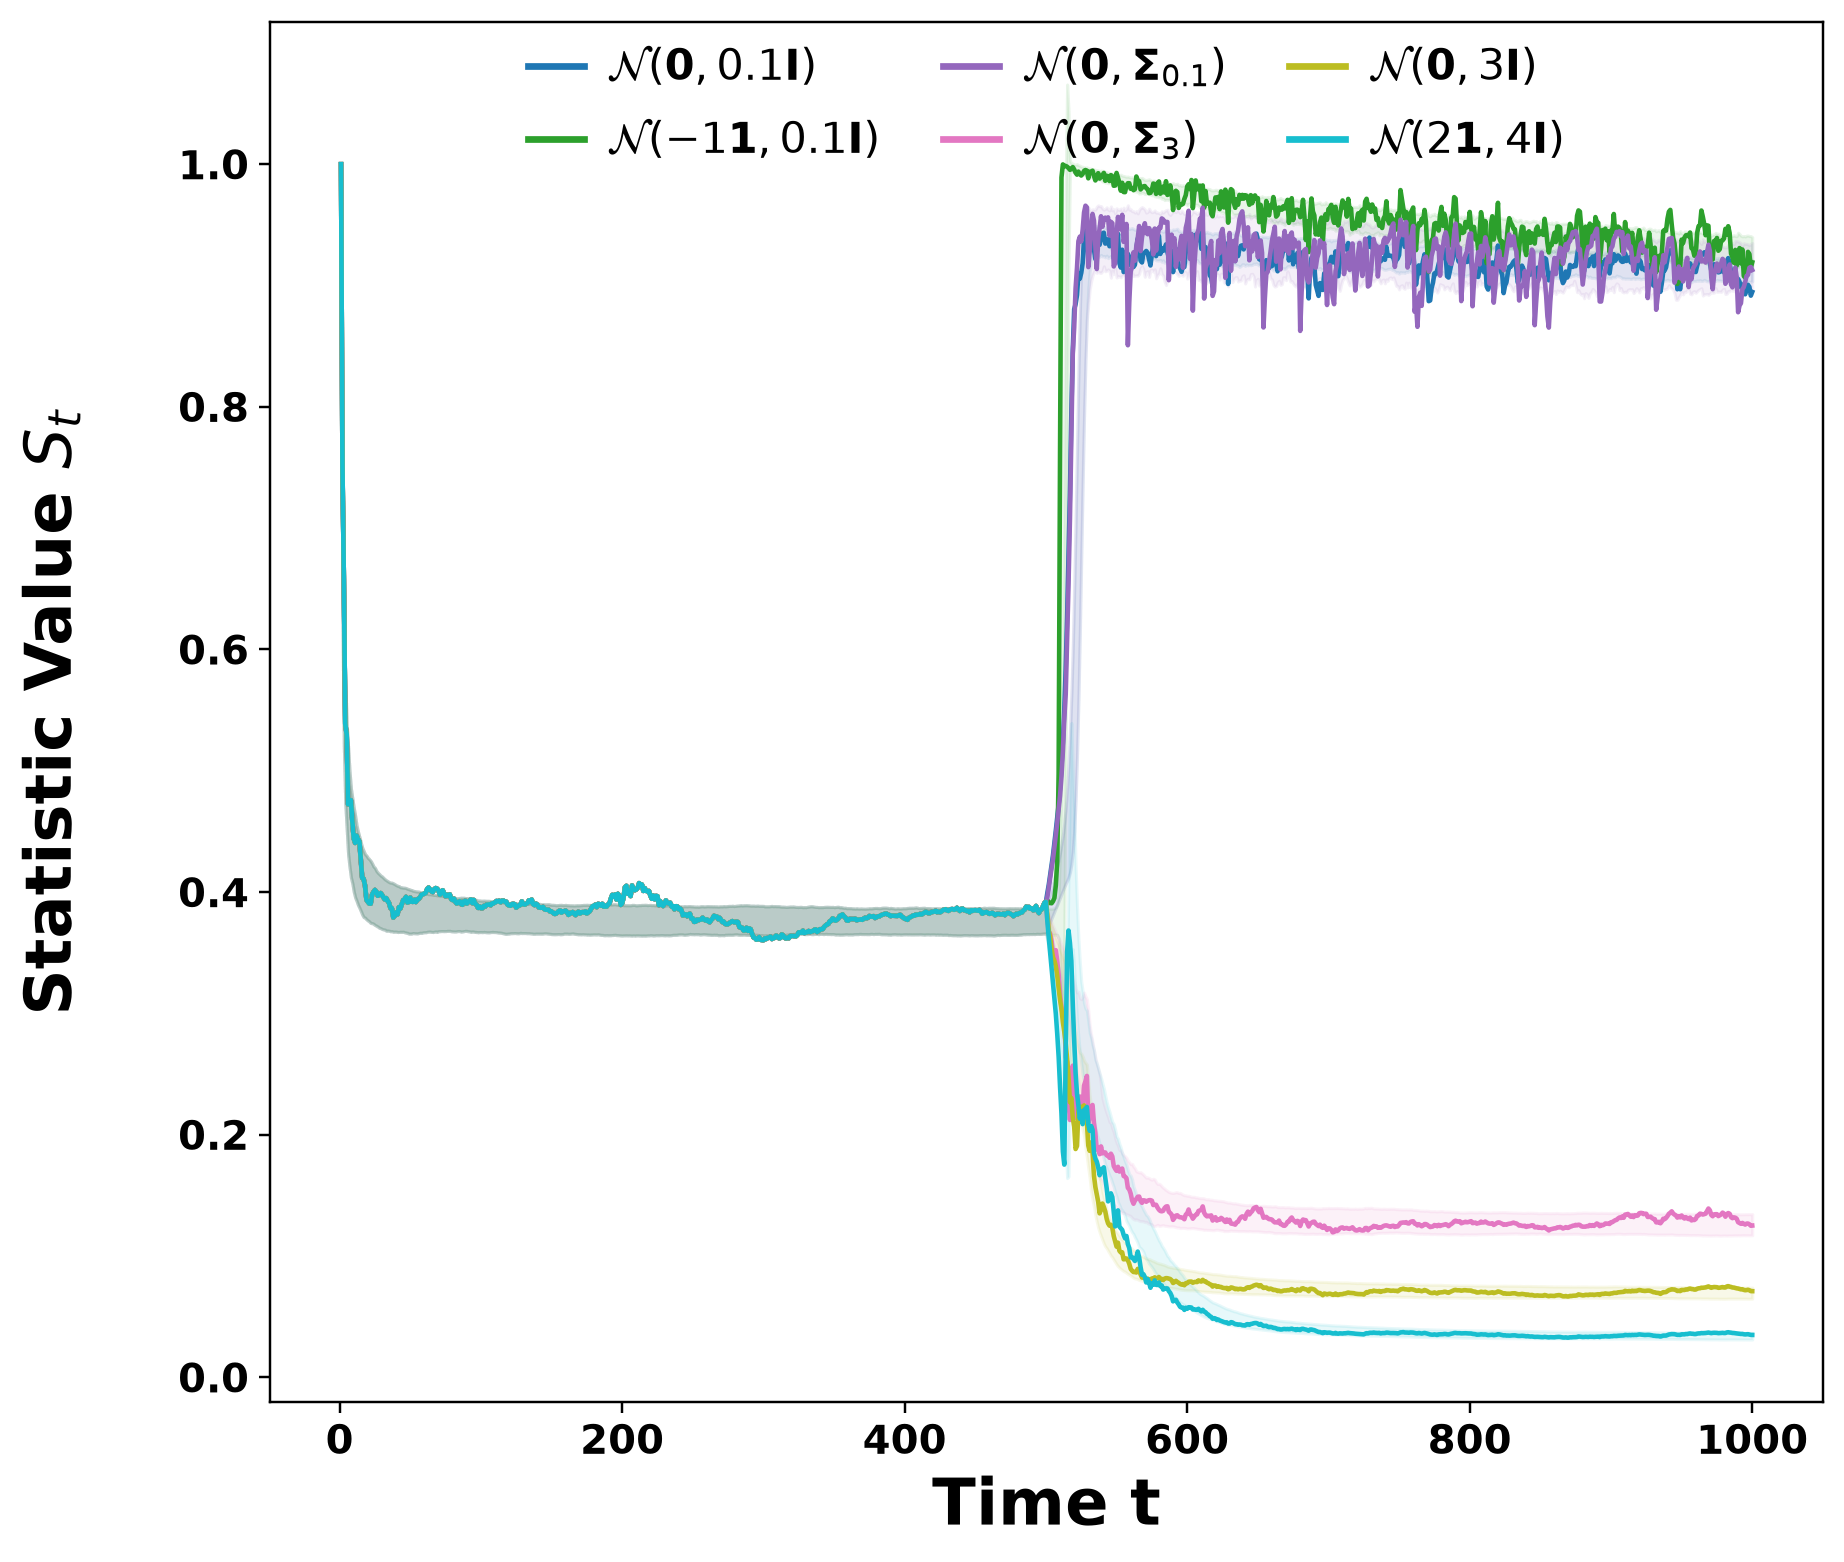

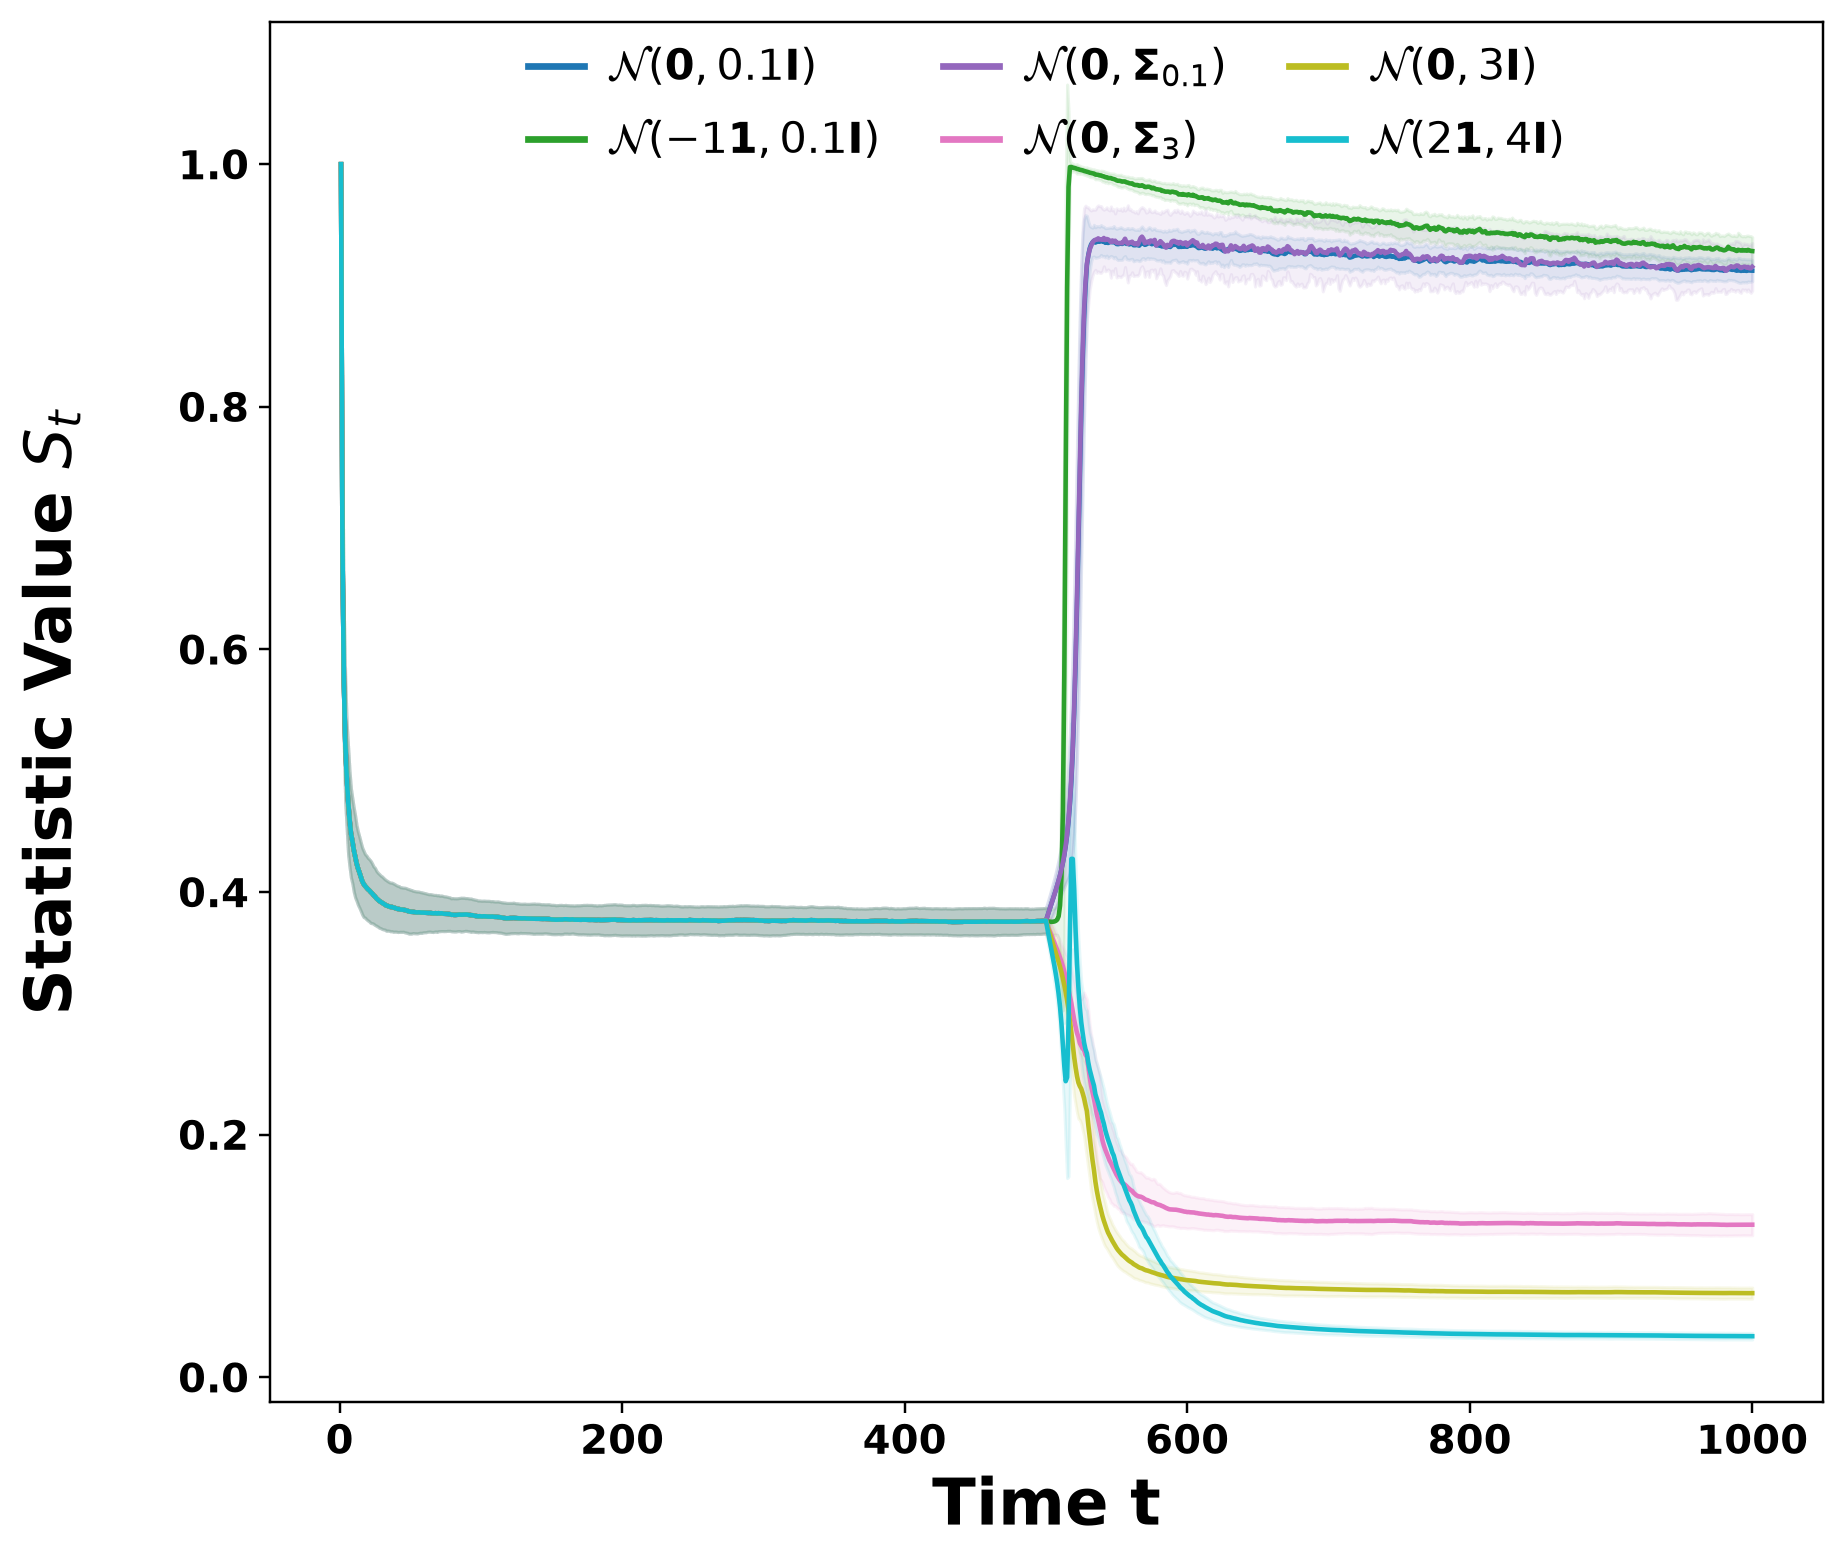

In [5]:
PATH_DIR.mkdir(parents=True, exist_ok=True)
combined_outputs = []
times = np.arange(1, PATH_HORIZON + 1)
colors = plt.cm.tab10(np.linspace(0, 1, max(len(GAUSSIAN_ALTERNATIVES), 2)))
for series_role in ("path", "mean"):
    fig, ax = plt.subplots(figsize=(8.5, 7.2))
    handles = []
    for color, (case_id, label, *_) in zip(colors, GAUSSIAN_ALTERNATIVES):
        stats = path_values[case_id]
        mean_path = stats.mean(axis=0)
        std_path = stats.std(axis=0, ddof=1)
        ax.fill_between(times, mean_path - std_path, mean_path + std_path,
                        color=color, alpha=0.10)
        ax.plot(times, mean_path if series_role == "mean" else stats[0],
                color=color, linewidth=1.5)
        handles.append(Line2D([0], [0], color=color, linewidth=2.2, label=label))
    ax.set_xlabel("Time t", fontsize=21, fontweight="bold")
    ax.set_ylabel(r"Statistic Value $S_t$", fontsize=21, fontweight="bold", labelpad=30)
    ax.tick_params(axis="both", labelsize=13)
    for tick in [*ax.get_xticklabels(), *ax.get_yticklabels()]:
        tick.set_fontweight("bold")
    ax.grid(False)
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.995),
              ncol=max(1, (len(handles) + 1) // 2), frameon=False, fontsize=14,
              columnspacing=1.45, labelspacing=0.65, handlelength=1.3,
              handletextpad=0.55, borderaxespad=0.0)
    fig.tight_layout()
    suffix = "individual_path_1" if series_role == "path" else "average_paths"
    png = PATH_DIR / f"all_gaussian_cases_{suffix}.png"
    pdf = png.with_suffix(".pdf")
    fig.savefig(png, dpi=220, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.close(fig)
    combined_outputs.append(png)
    print(f"Saved {png} and {pdf}")

try:
    from IPython.display import Image as IPImage, display
    for path in [*box_outputs, *combined_outputs]:
        display(IPImage(filename=str(path)))
except ImportError:
    pass
